# Day 17 - Advanced Matplotlib

---

**What you will learn today:**
- Colored scatter plots with colormaps and colorbars
- Annotations: plt.text, axhline, axvline, loop annotations
- Subplots: plt syntax vs fig/ax OOP syntax (the most important concept today)
- 3D plots: scatter3D, plot3D, surface plots with meshgrid
- Heatmaps using imshow and pivot_table
- Pandas .plot() for fast DataFrame visualization

---

**Why does this matter?**

Day 16 was basics - single charts, one at a time. Today you learn to build dashboards. A dashboard is multiple charts in one figure, each telling a different part of the same story. This is what you see in business reports, research papers, and data science portfolios.

By the end of today, you will be able to create a 2x2 dashboard like a professional data analyst.

## Setup

In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import os

os.makedirs('day17_charts', exist_ok=True)
np.random.seed(42)

print('All imports done.')

All imports done.


---

# Part 1: Colored Scatter Plots - Encoding a Third Variable

## The Concept

A normal scatter plot shows two variables: x-axis and y-axis. That is two dimensions of information.

But what if you have a third variable you want to show? You cannot add a third axis (well, you can, but it gets complicated). Instead, you encode the third variable using **color**.

This is called encoding. You are communicating information through visual properties - position (x, y), color, and size.

Example: Marks vs Attendance scatter, but color each dot based on the student's grade (A, B, C). Now one chart shows three variables.

---

## What is a Colormap (cmap)?

A colormap is a mapping from numbers to colors. You have a numerical variable (say, score 0-100) and you want to assign a color to each value. The colormap defines: what color does 0 get? What color does 50 get? What color does 100 get?

Popular colormaps and when to use them:

- **viridis** - goes from purple (low) to yellow (high). This is the industry standard for scientific work. It is colorblind-friendly and prints well in grayscale. Always use this in professional/academic work.

- **plasma** - goes from dark purple to bright yellow-white. Similar to viridis but more vivid. Also colorblind-friendly.

- **jet** - the famous rainbow colormap. Looks flashy but is misleading - the middle values (green) appear visually brighter than the extremes, creating false emphasis. Avoid in serious work. Legacy code uses it a lot, so you will see it.

- **coolwarm** - blue (low) to red (high). Perfect for showing negative vs positive, or below vs above average. Diverging colormap.

- **Blues, Greens, Reds** - single-color gradients, light to dark. Simple and clean for reports.

**Rule:** Use viridis or plasma for most work. Use coolwarm when your data has a meaningful midpoint (like 0, or the mean).

In [2]:
# --- DATA: Student marks, attendance, and scores ---
np.random.seed(42)
n_students = 80

attendance = np.random.uniform(40, 100, n_students)      # 40% to 100% attendance

# Marks loosely correlated with attendance (more attendance = slightly better marks)
marks = attendance * 0.6 + np.random.normal(0, 12, n_students)
marks = np.clip(marks, 20, 100)  # keep between 20 and 100

# A third variable: overall score (used for coloring)
overall_score = (marks * 0.7 + attendance * 0.3)  # weighted combination

print(f'Students: {n_students}')
print(f'Attendance range: {attendance.min():.1f}% to {attendance.max():.1f}%')
print(f'Marks range: {marks.min():.1f} to {marks.max():.1f}')

Students: 80
Attendance range: 40.3% to 99.2%
Marks range: 20.0 to 86.7


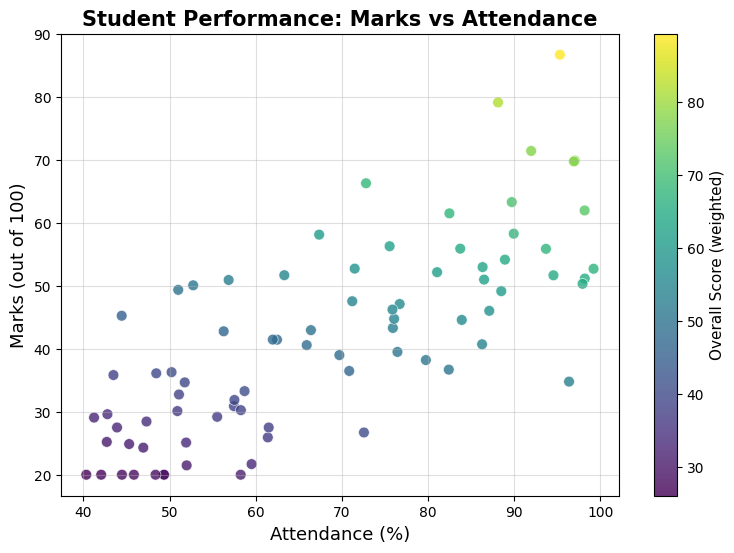

Colored scatter saved!


In [3]:
# --- COLORED SCATTER PLOT ---
plt.figure(figsize=(9, 6))

# c=overall_score maps the overall_score values to colors
# Matplotlib looks at the min and max of overall_score and maps that range to the colormap
sc = plt.scatter(
    attendance,
    marks,
    c=overall_score,         # THIS is what makes dots colored by a third variable
    cmap='viridis',          # the color mapping
    s=60,                    # dot size (uniform here)
    alpha=0.8,               # slight transparency so overlapping dots are visible
    edgecolors='white',      # white border around each dot - adds clarity
    linewidths=0.5
)

# Colorbar: the vertical legend that explains what colors mean
# Without this, the viewer cannot interpret the colors
cbar = plt.colorbar(sc)
cbar.set_label('Overall Score (weighted)', fontsize=11)

plt.title('Student Performance: Marks vs Attendance', fontsize=15, fontweight='bold')
plt.xlabel('Attendance (%)', fontsize=13)
plt.ylabel('Marks (out of 100)', fontsize=13)
plt.grid(True, alpha=0.4)

plt.savefig('day17_charts/1_colored_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Colored scatter saved!')

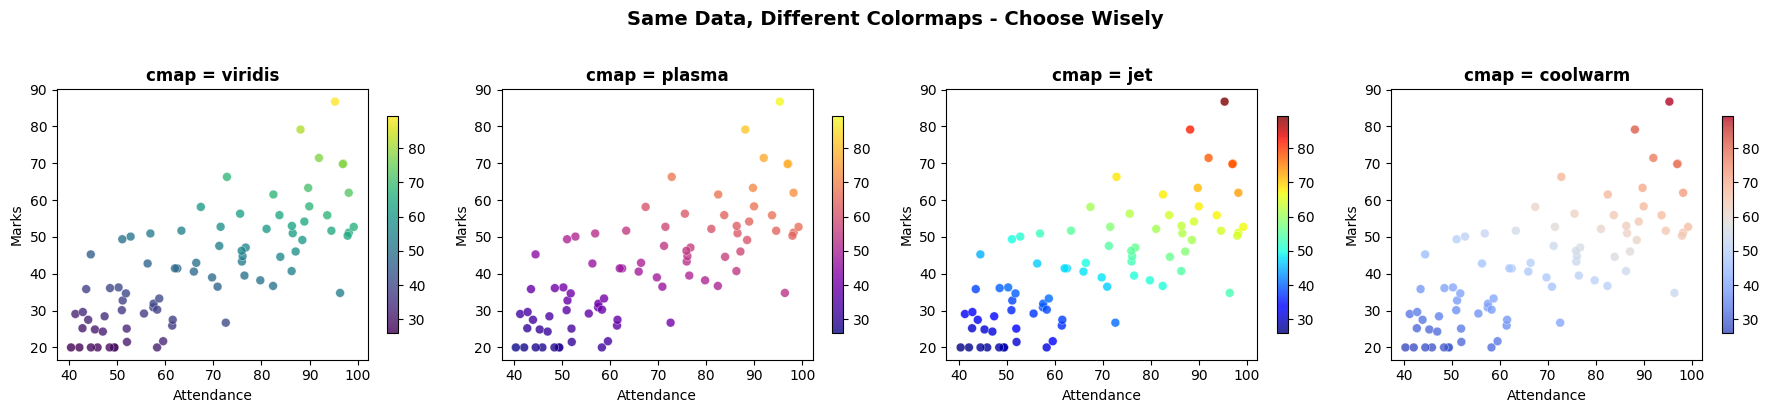

Note: viridis and plasma are perceptually uniform - each step looks equally different.
jet is NOT - the green section looks brighter, creating a false visual peak.


In [4]:
# Comparing different colormaps side by side
# This is a learning exercise - see how the same data looks with different cmaps

cmaps_to_compare = ['viridis', 'plasma', 'jet', 'coolwarm']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, cmap_name in zip(axes, cmaps_to_compare):
    sc = ax.scatter(attendance, marks, c=overall_score, cmap=cmap_name,
                    s=40, alpha=0.8, edgecolors='white', linewidths=0.3)
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_title(f'cmap = {cmap_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Attendance')
    ax.set_ylabel('Marks')

fig.suptitle('Same Data, Different Colormaps - Choose Wisely', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('day17_charts/1b_cmap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: viridis and plasma are perceptually uniform - each step looks equally different.')
print('jet is NOT - the green section looks brighter, creating a false visual peak.')

---

# Part 2: Annotations - Adding Context to Charts

## Why Annotations Matter

A chart without annotations is like a map without labels. You can see shapes but you cannot understand what they mean.

Annotations let you:
- Point out specific data points ("this is the outlier")
- Add reference lines ("this is the class average")
- Explain what the viewer is looking at

In professional data science work, every chart that gets shared with non-technical people needs annotations. Otherwise they ask: "so what am I supposed to look at here?"

---

## The Four Annotation Tools

1. `plt.text(x, y, 'text')` - places text at a specific data coordinate. Simple, no arrow.

2. `plt.annotate('text', xy=point, xytext=text_position, arrowprops=...)` - places text with an arrow pointing to a specific point. More powerful.

3. `plt.axhline(y=value)` - draws a horizontal line across the entire plot at a given y-value. Perfect for showing averages, thresholds, targets.

4. `plt.axvline(x=value)` - same but vertical. Perfect for showing dates, cutoffs.

In [5]:
# Create some student data for annotation demonstration
np.random.seed(10)
n = 30
student_ids = [f'S{i:02d}' for i in range(1, n+1)]
exam_score = np.random.normal(65, 15, n)
exam_score = np.clip(exam_score, 20, 100)
project_score = np.random.normal(70, 12, n)
project_score = np.clip(project_score, 20, 100)

mean_exam = exam_score.mean()
mean_project = project_score.mean()

# Find the top performer and the struggling student
combined = exam_score + project_score
top_idx = combined.argmax()
low_idx = combined.argmin()

print(f'Mean exam score: {mean_exam:.1f}')
print(f'Mean project score: {mean_project:.1f}')
print(f'Top performer: {student_ids[top_idx]} (combined: {combined[top_idx]:.0f})')
print(f'Needs attention: {student_ids[low_idx]} (combined: {combined[low_idx]:.0f})')

Mean exam score: 67.9
Mean project score: 71.4
Top performer: S24 (combined: 178)
Needs attention: S21 (combined: 105)


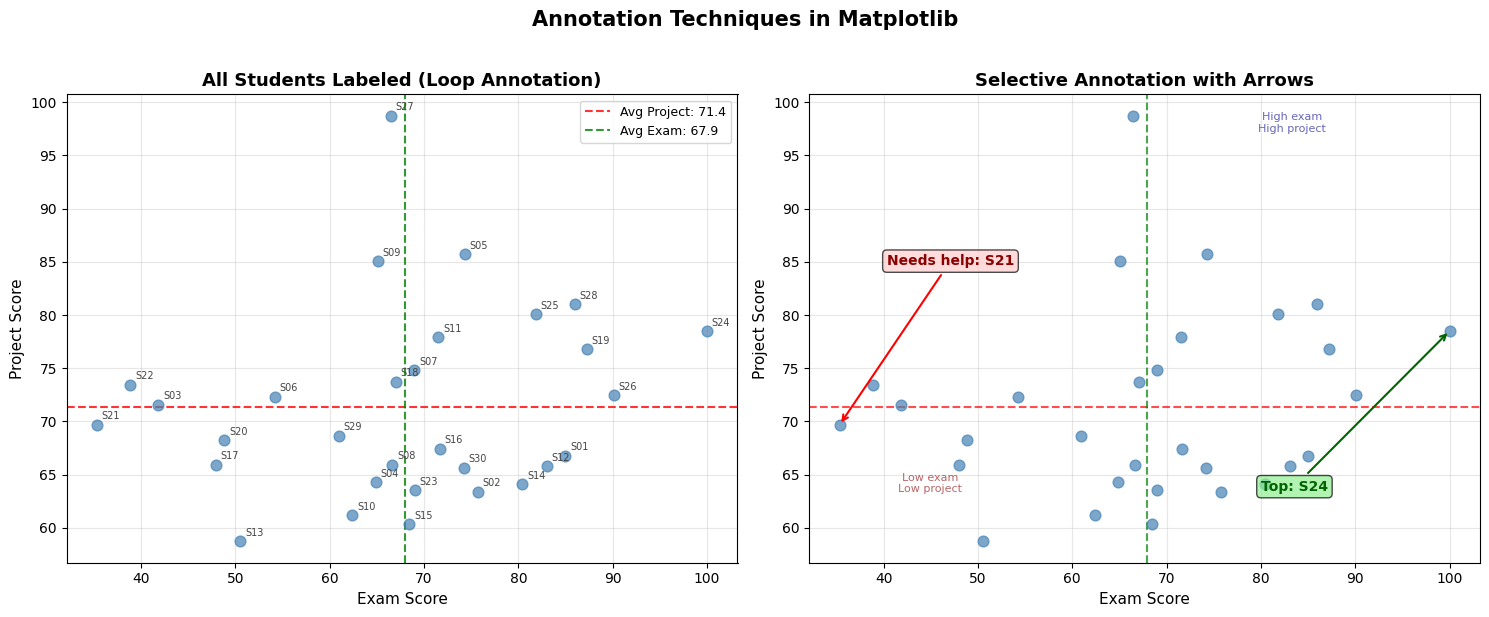

Annotation examples saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- LEFT CHART: Loop annotations (labeling every point) ---
ax = axes[0]
ax.scatter(exam_score, project_score, color='steelblue', s=60, alpha=0.7, zorder=3)

# Loop through every point and annotate with student ID
# fontdict is a dictionary that sets multiple font properties at once
fontdict = {'fontsize': 7, 'color': '#444444'}

for i in range(n):
    ax.text(
        exam_score[i] + 0.5,    # x: slightly right of the dot
        project_score[i] + 0.5, # y: slightly above the dot
        student_ids[i],          # the text to display
        fontdict=fontdict
    )

# axhline: horizontal reference line at mean project score
# linestyle, color, linewidth, label all work same as plt.plot()
ax.axhline(y=mean_project, color='red', linestyle='--', linewidth=1.5,
           label=f'Avg Project: {mean_project:.1f}', alpha=0.8)

# axvline: vertical reference line at mean exam score
ax.axvline(x=mean_exam, color='green', linestyle='--', linewidth=1.5,
           label=f'Avg Exam: {mean_exam:.1f}', alpha=0.8)

ax.set_title('All Students Labeled (Loop Annotation)', fontsize=13, fontweight='bold')
ax.set_xlabel('Exam Score', fontsize=11)
ax.set_ylabel('Project Score', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- RIGHT CHART: Selective annotation with arrows ---
ax2 = axes[1]
ax2.scatter(exam_score, project_score, color='steelblue', s=60, alpha=0.7, zorder=3)

ax2.axhline(y=mean_project, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axvline(x=mean_exam, color='green', linestyle='--', linewidth=1.5, alpha=0.7)

# Only annotate the interesting points: top and low
# plt.annotate:
#   text       - what to write
#   xy         - the point the arrow points TO (the data point)
#   xytext     - where to place the text box
#   arrowprops - dictionary controlling the arrow style
#   fontsize, color, bbox - styling

ax2.annotate(
    f'Top: {student_ids[top_idx]}',
    xy=(exam_score[top_idx], project_score[top_idx]),
    xytext=(exam_score[top_idx] - 20, project_score[top_idx] - 15),
    arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5),
    fontsize=10, color='darkgreen', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7)
)

ax2.annotate(
    f'Needs help: {student_ids[low_idx]}',
    xy=(exam_score[low_idx], project_score[low_idx]),
    xytext=(exam_score[low_idx] + 5, project_score[low_idx] + 15),
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
    fontsize=10, color='darkred', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffcccc', alpha=0.7)
)

# Add quadrant labels using plt.text with transform
# transform=ax2.transAxes means x and y are in AXES coordinates (0-1) not data coordinates
# This is useful when you want to place text relative to the chart, not the data
ax2.text(0.72, 0.92, 'High exam\nHigh project', transform=ax2.transAxes,
         fontsize=8, color='darkblue', alpha=0.6, ha='center')
ax2.text(0.18, 0.15, 'Low exam\nLow project', transform=ax2.transAxes,
         fontsize=8, color='darkred', alpha=0.6, ha='center')

ax2.set_title('Selective Annotation with Arrows', fontsize=13, fontweight='bold')
ax2.set_xlabel('Exam Score', fontsize=11)
ax2.set_ylabel('Project Score', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle('Annotation Techniques in Matplotlib', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('day17_charts/2_annotations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Annotation examples saved!')

### What you just learned about Annotations:

- `ax.text(x, y, 'text', fontdict={})` - text at data coordinates. `fontdict` bundles font settings.
- `ax.annotate('text', xy=point, xytext=label_pos, arrowprops={})` - arrow annotation pointing to a specific data point.
- `arrowprops=dict(arrowstyle='->', color='red', lw=1.5)` - controls the arrow appearance.
- `bbox=dict(boxstyle='round', facecolor='yellow')` - adds a box around annotation text.
- `ax.axhline(y=value)` - horizontal reference line across entire chart.
- `ax.axvline(x=value)` - vertical reference line across entire chart.
- `transform=ax.transAxes` - switches coordinate system to 0-1 axes coordinates, not data coordinates.

**When to loop-annotate vs selectively annotate:**
- Loop annotate: only when you have fewer than 20 points. More than that gets cluttered.
- Selective annotation: always. Find the most interesting points and highlight them. This is what a storytelling chart looks like.

---

# Part 3: Subplots - The Most Important Concept Today

## The Problem Without Subplots

If you have 4 related charts, you could create 4 separate figures. But then they are disconnected. A viewer has to look at 4 different images to understand the story.

Subplots let you put multiple charts inside ONE figure, arranged in a grid. This is how dashboards are built.

---

## plt syntax vs fig/ax OOP syntax - Know This for Interviews

There are two completely different ways to use Matplotlib. Both produce the same output, but they work differently underneath.

### Method 1: plt syntax (quick and simple)
```python
plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.title('My Chart')
plt.xlabel('X')
plt.show()
```
You call everything on `plt` directly. Matplotlib keeps track of which figure and axes are "current" and applies your commands there.

**Problem:** When you have multiple subplots, `plt` gets confused about which axes is "current". You end up fighting with the library.

**Use plt syntax for:** single quick charts, exploration, Jupyter notebooks.

### Method 2: fig/ax OOP syntax (explicit and professional)
```python
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y)
ax.set_title('My Chart')
ax.set_xlabel('X')
plt.show()
```
You create explicit `fig` (the figure/canvas) and `ax` (the axes/chart area) objects. Then you call methods ON those objects.

**Key difference:** `plt.title()` vs `ax.set_title()`. With OOP, everything is `set_` prefixed.

**Use fig/ax syntax for:** multiple subplots, production code, anything you will share or maintain.

### For subplots:
```python
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
# axes is now a 2D array: axes[0][0], axes[0][1], axes[1][0], axes[1][1]
```

Each `axes[i][j]` is a separate chart area. You call methods on each one independently.

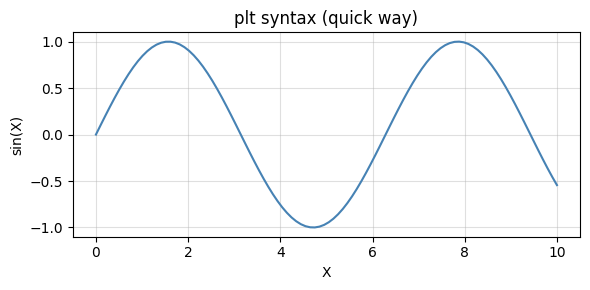

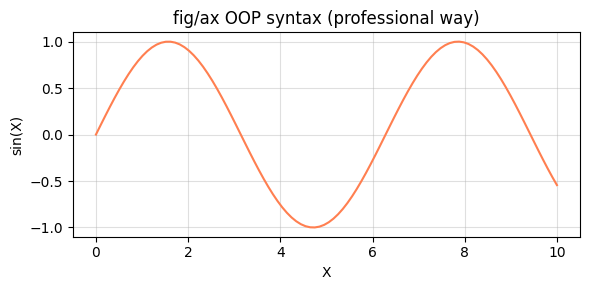

Both charts look identical. The difference is in HOW you write the code.
fig/ax syntax gives you explicit control - critical for subplots.


In [7]:
# DEMONSTRATION: plt syntax vs fig/ax syntax - same output, different code

x = np.linspace(0, 10, 100)
y = np.sin(x)

# --- METHOD 1: plt syntax ---
plt.figure(figsize=(6, 3))
plt.plot(x, y, color='steelblue')
plt.title('plt syntax (quick way)')
plt.xlabel('X')
plt.ylabel('sin(X)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# --- METHOD 2: fig/ax OOP syntax ---
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x, y, color='coral')
ax.set_title('fig/ax OOP syntax (professional way)')  # note: set_title not title
ax.set_xlabel('X')                                     # note: set_xlabel not xlabel
ax.set_ylabel('sin(X)')                                # note: set_ylabel not ylabel
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('Both charts look identical. The difference is in HOW you write the code.')
print('fig/ax syntax gives you explicit control - critical for subplots.')

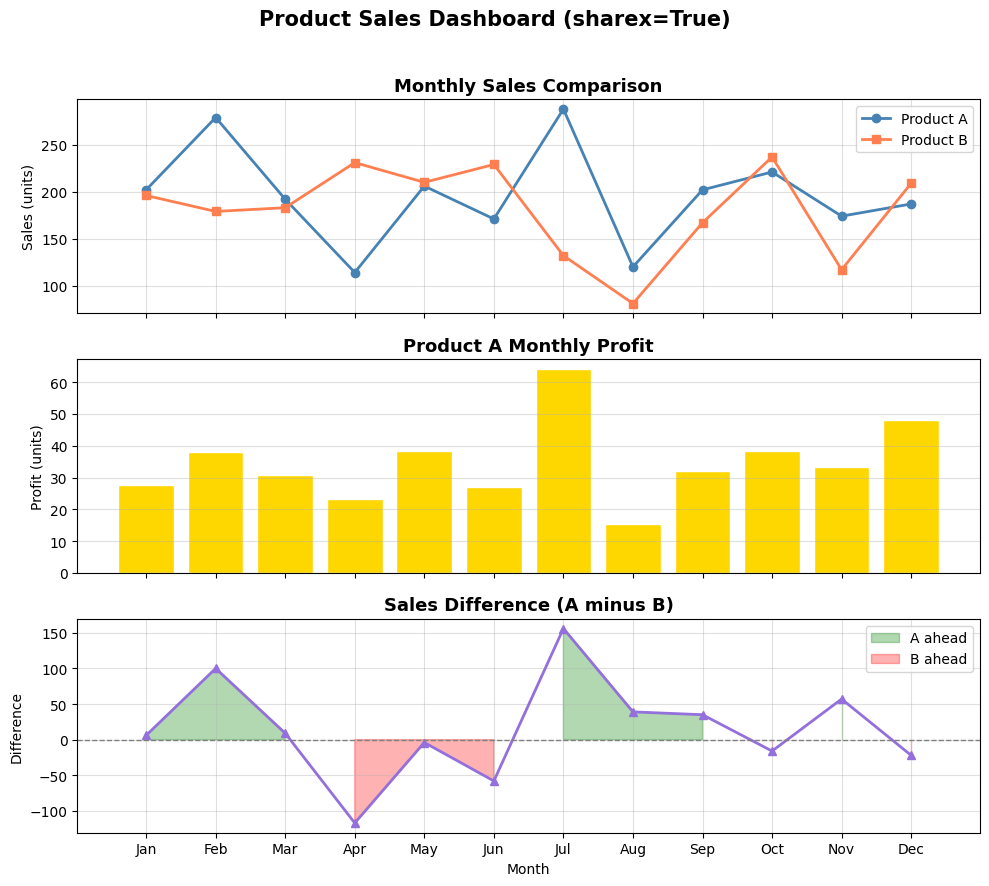

Subplots with sharex saved!


In [8]:
# SUBPLOTS: nrows, ncols, sharex, sharey

# sharex=True means all subplots share the same x-axis
# When you zoom in on one, all zoom together
# sharey=True same but for y-axis
# Useful when charts show different aspects of the same x range (time, for example)

np.random.seed(42)
months = np.arange(1, 13)
sales_A = np.random.randint(100, 300, 12)
sales_B = np.random.randint(80, 250, 12)
profit_A = sales_A * np.random.uniform(0.1, 0.3, 12)

# Create 3 rows, 1 column. Share x-axis across all.
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 9), sharex=True)

# axes[0] = top chart
axes[0].plot(months, sales_A, color='steelblue', marker='o', linewidth=2, label='Product A')
axes[0].plot(months, sales_B, color='coral', marker='s', linewidth=2, label='Product B')
axes[0].set_title('Monthly Sales Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales (units)')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# axes[1] = middle chart
axes[1].bar(months, profit_A, color='gold', edgecolor='white')
axes[1].set_title('Product A Monthly Profit', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit (units)')
axes[1].grid(True, alpha=0.4, axis='y')

# axes[2] = bottom chart
axes[2].plot(months, (sales_A - sales_B), color='mediumpurple', linewidth=2, marker='^')
axes[2].axhline(y=0, color='gray', linestyle='--', linewidth=1)
axes[2].fill_between(months, 0, (sales_A - sales_B),
                     where=(sales_A > sales_B), alpha=0.3, color='green', label='A ahead')
axes[2].fill_between(months, 0, (sales_A - sales_B),
                     where=(sales_A <= sales_B), alpha=0.3, color='red', label='B ahead')
axes[2].set_title('Sales Difference (A minus B)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Difference')
axes[2].set_xlabel('Month')
axes[2].legend()
axes[2].grid(True, alpha=0.4)

# Month names on x-axis (only needed on bottom chart since sharex=True)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].set_xticks(months)
axes[2].set_xticklabels(month_names)

# fig.suptitle = title for the entire figure (above all subplots)
fig.suptitle('Product Sales Dashboard (sharex=True)', fontsize=15, fontweight='bold')

# plt.tight_layout() automatically adjusts spacing between subplots so they don't overlap
# rect=[0, 0, 1, 0.96] leaves space for suptitle at the top
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('day17_charts/3_subplots_sharex.png', dpi=150, bbox_inches='tight')
plt.show()
print('Subplots with sharex saved!')

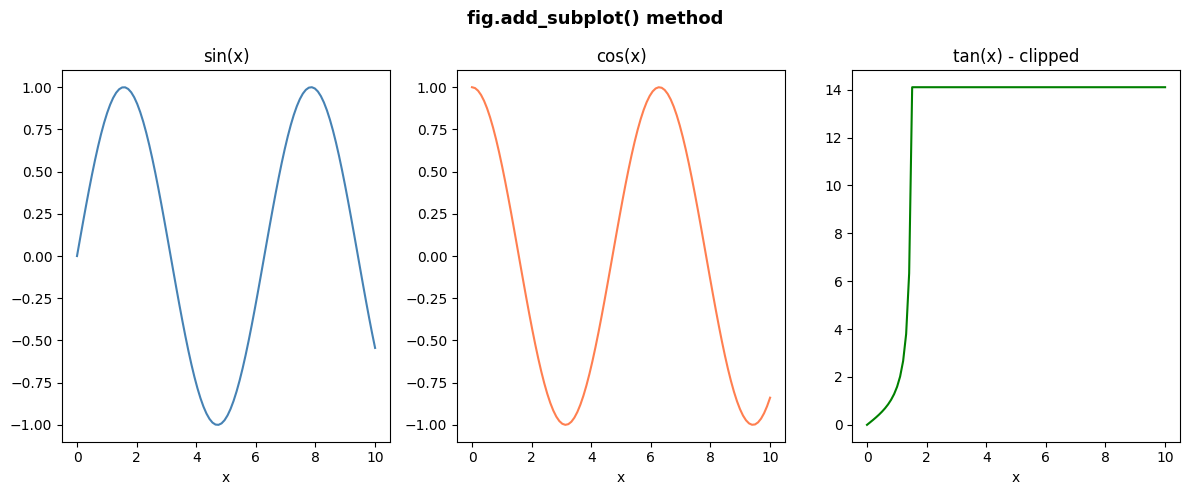

add_subplot demonstration done.
Use plt.subplots() for clean grids.
Use fig.add_subplot() when you need more control over layout.


In [9]:
# fig.add_subplot() - alternative way to add subplots one at a time
# Useful when you want irregular layouts (not a clean grid)

# add_subplot(nrows, ncols, index)
# index counts left-to-right, top-to-bottom, starting from 1

fig = plt.figure(figsize=(12, 5))

# Subplot 1: takes position 1 in a 1x3 grid (left)
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(x, np.sin(x), color='steelblue')
ax1.set_title('sin(x)')
ax1.set_xlabel('x')

# Subplot 2: takes position 2 in a 1x3 grid (middle)
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(x, np.cos(x), color='coral')
ax2.set_title('cos(x)')
ax2.set_xlabel('x')

# Subplot 3: takes position 3 in a 1x3 grid (right)
ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(x, np.tan(np.clip(x, 0, 1.5)), color='green')  # clip to avoid tan blowing up
ax3.set_title('tan(x) - clipped')
ax3.set_xlabel('x')

fig.suptitle('fig.add_subplot() method', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('add_subplot demonstration done.')
print('Use plt.subplots() for clean grids.')
print('Use fig.add_subplot() when you need more control over layout.')

---

# Part 4: 3D Plots

## When Do You Actually Need 3D?

3D plots look impressive but they are often NOT the best choice. The problem is that a 3D chart on a 2D screen can be misleading - depth is hard to judge, some points get hidden behind others, and the chart becomes hard to read.

Use 3D plots when:
- You genuinely have three numerical variables and want to explore their relationship
- You are showing a mathematical surface (sin waves, optimization landscapes)
- The 3D structure IS the message (not just a fancy decoration)

For everything else, use 2D charts with color encoding for the third variable.

---

## How 3D Axes Work

You create a 3D axes by passing `projection='3d'` when creating the subplot. This gives you an axes object that understands three dimensions.

The import `from mpl_toolkits.mplot3d import Axes3D` registers the 3D projection. In newer versions of Matplotlib this happens automatically, but it is good practice to import it explicitly.

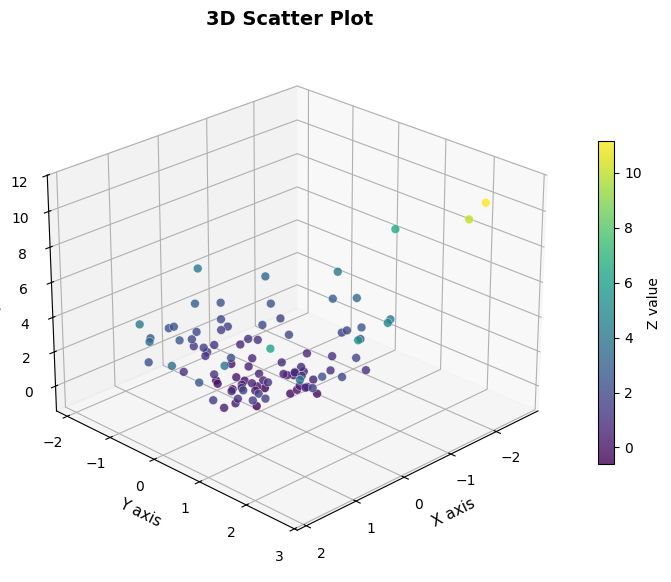

3D scatter saved!


In [10]:
# --- 3D SCATTER PLOT ---
np.random.seed(42)
n_3d = 100

x_3d = np.random.normal(0, 1, n_3d)
y_3d = np.random.normal(0, 1, n_3d)
z_3d = x_3d**2 + y_3d**2 + np.random.normal(0, 0.5, n_3d)  # z roughly = x^2 + y^2

fig = plt.figure(figsize=(10, 7))

# projection='3d' is the key - this creates a 3D axes object
ax = fig.add_subplot(111, projection='3d')

# scatter3D works like plt.scatter but takes x, y, z
# c=z_3d colors dots by their z-value (height)
sc = ax.scatter3D(x_3d, y_3d, z_3d, c=z_3d, cmap='viridis',
                  s=40, alpha=0.8, edgecolors='white', linewidths=0.3)
plt.colorbar(sc, ax=ax, shrink=0.6, label='Z value')

ax.set_title('3D Scatter Plot', fontsize=14, fontweight='bold')
ax.set_xlabel('X axis', fontsize=11)
ax.set_ylabel('Y axis', fontsize=11)
ax.set_zlabel('Z axis', fontsize=11)  # zlabel is unique to 3D axes

# view_init sets the viewing angle
# elev = elevation angle (how high up you are looking from)
# azim = azimuthal angle (which direction you are looking from)
ax.view_init(elev=25, azim=45)

plt.savefig('day17_charts/4a_3d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('3D scatter saved!')

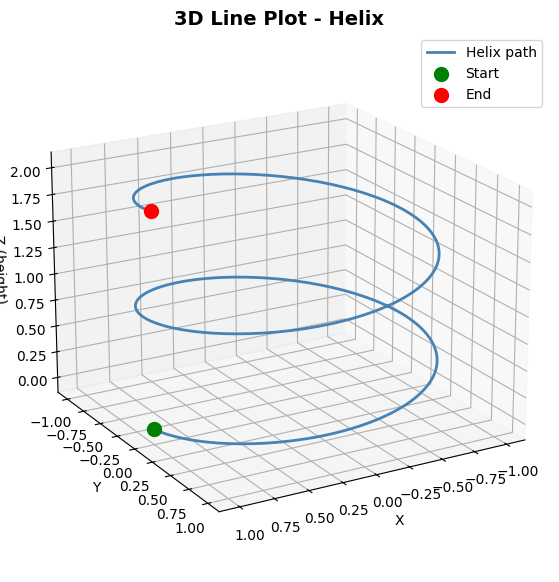

3D line saved!


In [11]:
# --- 3D LINE PLOT ---
# A 3D line is useful for showing trajectories, paths, or parametric curves

t = np.linspace(0, 4 * np.pi, 300)  # parameter t from 0 to 4*pi

# Parametric helix: as t increases, x and y trace a circle, z increases linearly
x_helix = np.cos(t)
y_helix = np.sin(t)
z_helix = t / (2 * np.pi)  # rises steadily

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# plot3D = 3D line. Works like plt.plot but with z argument
ax.plot3D(x_helix, y_helix, z_helix, color='steelblue', linewidth=2, label='Helix path')

# Mark start and end points
ax.scatter3D([x_helix[0]], [y_helix[0]], [z_helix[0]],
             color='green', s=100, zorder=5, label='Start')
ax.scatter3D([x_helix[-1]], [y_helix[-1]], [z_helix[-1]],
             color='red', s=100, zorder=5, label='End')

ax.set_title('3D Line Plot - Helix', fontsize=14, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z (height)')
ax.legend(fontsize=10)
ax.view_init(elev=20, azim=60)

plt.savefig('day17_charts/4b_3d_line.png', dpi=150, bbox_inches='tight')
plt.show()
print('3D line saved!')

---

# Part 5: Meshgrid and Surface Plots

## What is np.meshgrid?

This is a concept that confuses many beginners. Let me explain it clearly.

Suppose you want to evaluate a function f(x, y) at every combination of x and y values. For example, x goes from -3 to 3 and y goes from -3 to 3, and you want to know f(x, y) = sin(x) * cos(y) at every (x, y) grid point.

You have:
- x_values = [-3, -2, -1, 0, 1, 2, 3] (7 values)
- y_values = [-3, -2, -1, 0, 1, 2, 3] (7 values)
- You want to evaluate f at all 7 x 7 = 49 combinations

`np.meshgrid(x_values, y_values)` takes these two 1D arrays and returns two 2D arrays (XX and YY) where:
- XX[i][j] = x value for grid point (i, j)
- YY[i][j] = y value for grid point (i, j)

Now you can just write `ZZ = np.sin(XX) * np.cos(YY)` and NumPy evaluates the function at all 49 points simultaneously.

Then `plot_surface(XX, YY, ZZ)` draws a 3D surface through all those points.

**Real-world use:** Visualizing cost functions in machine learning, optimization landscapes, heat distributions, wave patterns.

In [12]:
# Step by step meshgrid explanation

x_small = np.array([1, 2, 3])
y_small = np.array([10, 20, 30])

XX, YY = np.meshgrid(x_small, y_small)

print('x_small:', x_small)
print('y_small:', y_small)
print()
print('XX (x repeated for each y):')
print(XX)
print()
print('YY (y repeated for each x):')
print(YY)
print()
print('Now XX + YY gives f(x,y) = x+y at every grid point:')
print(XX + YY)
print()
print('See? Row 0 is 1+10, 2+10, 3+10 | Row 1 is 1+20, 2+20, 3+20 | etc.')

x_small: [1 2 3]
y_small: [10 20 30]

XX (x repeated for each y):
[[1 2 3]
 [1 2 3]
 [1 2 3]]

YY (y repeated for each x):
[[10 10 10]
 [20 20 20]
 [30 30 30]]

Now XX + YY gives f(x,y) = x+y at every grid point:
[[11 12 13]
 [21 22 23]
 [31 32 33]]

See? Row 0 is 1+10, 2+10, 3+10 | Row 1 is 1+20, 2+20, 3+20 | etc.


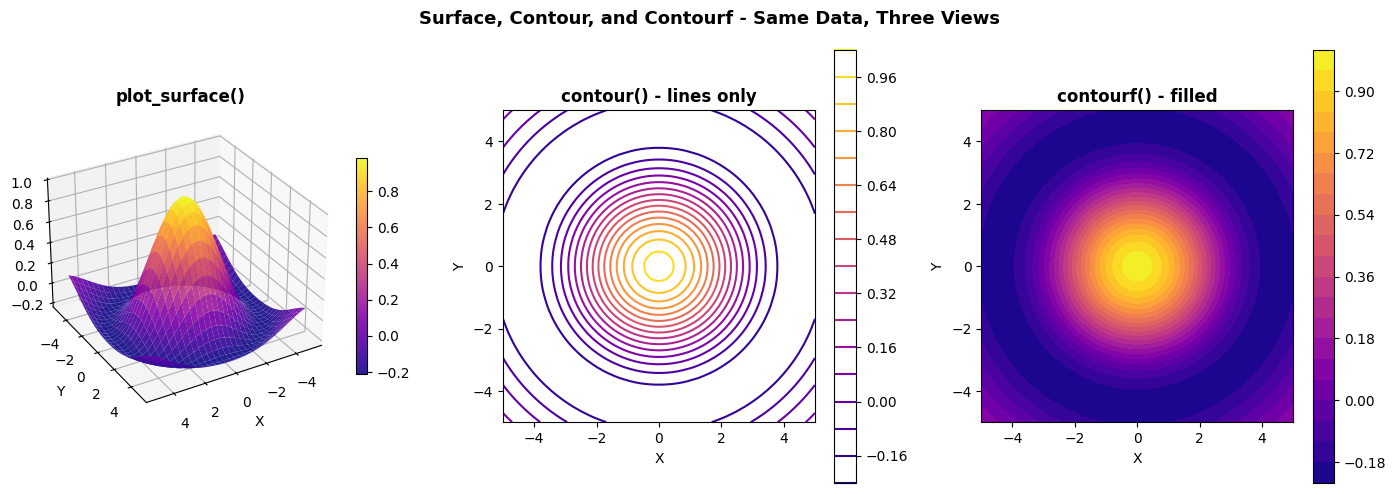

Surface and contour plots saved!


In [13]:
# --- SURFACE PLOT: sin wave ---

# Create a fine grid from -5 to 5
x_range = np.linspace(-5, 5, 60)
y_range = np.linspace(-5, 5, 60)
XX, YY = np.meshgrid(x_range, y_range)

# Define the surface: z = sin(sqrt(x^2 + y^2)) - the classic "ripple" function
# sqrt(x^2 + y^2) is the distance from center (0,0)
# sin of distance creates circular ripples
R = np.sqrt(XX**2 + YY**2)
ZZ = np.sin(R) / (R + 0.001)  # +0.001 to avoid division by zero at center

fig = plt.figure(figsize=(14, 5))

# --- Surface plot ---
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
surf = ax1.plot_surface(XX, YY, ZZ, cmap='plasma', alpha=0.9)
plt.colorbar(surf, ax=ax1, shrink=0.5)
ax1.set_title('plot_surface()', fontsize=12, fontweight='bold')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.view_init(elev=30, azim=60)

# --- Contour plot (top-down view with lines) ---
# Contour lines are like the lines on a topographic map
# Each line connects all points at the same Z (height) value
ax2 = fig.add_subplot(1, 3, 2)
contour = ax2.contour(XX, YY, ZZ, levels=15, cmap='plasma')
plt.colorbar(contour, ax=ax2)
ax2.set_title('contour() - lines only', fontsize=12, fontweight='bold')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_aspect('equal')

# --- Contourf (filled contours) ---
# Same as contour but fills the areas between contour lines with color
# This is the 2D top-down view of a surface - very common in publications
ax3 = fig.add_subplot(1, 3, 3)
cf = ax3.contourf(XX, YY, ZZ, levels=20, cmap='plasma')
plt.colorbar(cf, ax=ax3)
ax3.set_title('contourf() - filled', fontsize=12, fontweight='bold')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_aspect('equal')

fig.suptitle('Surface, Contour, and Contourf - Same Data, Three Views', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day17_charts/5_surface_contour.png', dpi=150, bbox_inches='tight')
plt.show()
print('Surface and contour plots saved!')

### What you just learned about 3D and Surfaces:

- `projection='3d'` in `add_subplot()` creates a 3D axes.
- `ax.scatter3D(x, y, z)` - 3D scatter plot.
- `ax.plot3D(x, y, z)` - 3D line plot.
- `ax.set_zlabel()` - z-axis label (only exists on 3D axes).
- `ax.view_init(elev, azim)` - change the viewing angle.
- `np.meshgrid(x, y)` - creates 2D grids from 1D arrays. Essential for surface plots.
- `ax.plot_surface(XX, YY, ZZ, cmap=)` - 3D surface. Needs meshgrid format.
- `ax.contour()` - 2D topographic-style contour lines.
- `ax.contourf()` - same but filled with color. More readable than contour lines.

---

# Part 6: Heatmap Using imshow

## What is a Heatmap?

A heatmap displays a 2D matrix of numbers as colors. Rows are one category, columns are another category, and the cell color represents the value at that (row, column) intersection.

Classic uses:
- Correlation matrix: which features correlate with each other?
- Student x Subject marks matrix: who scored well in which subject?
- Hour x Day activity matrix: when is the app used most?

---

## How to Create a Heatmap

You need a 2D NumPy array or a pivot table. Then `ax.imshow(data, cmap=)` renders it as a colored grid.

`imshow` literally means "image show" - it treats your matrix like an image where each cell is a pixel colored by its value.

For real DataFrames, `pd.pivot_table()` reshapes your data into the 2D format needed.

In [14]:
# --- DATA: Student x Subject marks matrix ---
np.random.seed(7)

students = ['Arjun', 'Priya', 'Rahul', 'Sneha', 'Vikram', 'Deepa', 'Amit', 'Kavya']
subjects = ['Math', 'Physics', 'Chemistry', 'Biology', 'English', 'History']

# Create realistic marks: some students are strong in science, others in humanities
marks_matrix = np.array([
    [92, 88, 85, 70, 65, 60],  # Arjun - strong in science
    [65, 70, 68, 88, 92, 90],  # Priya - strong in humanities
    [78, 75, 80, 72, 68, 65],  # Rahul - average across
    [88, 85, 90, 92, 75, 70],  # Sneha - strong in science and bio
    [95, 92, 88, 65, 60, 55],  # Vikram - very strong in math/physics
    [55, 60, 58, 75, 88, 92],  # Deepa - humanities focused
    [72, 68, 75, 70, 72, 68],  # Amit - consistent average
    [85, 80, 78, 88, 82, 80],  # Kavya - good all-rounder
])

print('Marks matrix shape:', marks_matrix.shape)
print('Rows = students, Columns = subjects')

Marks matrix shape: (8, 6)
Rows = students, Columns = subjects


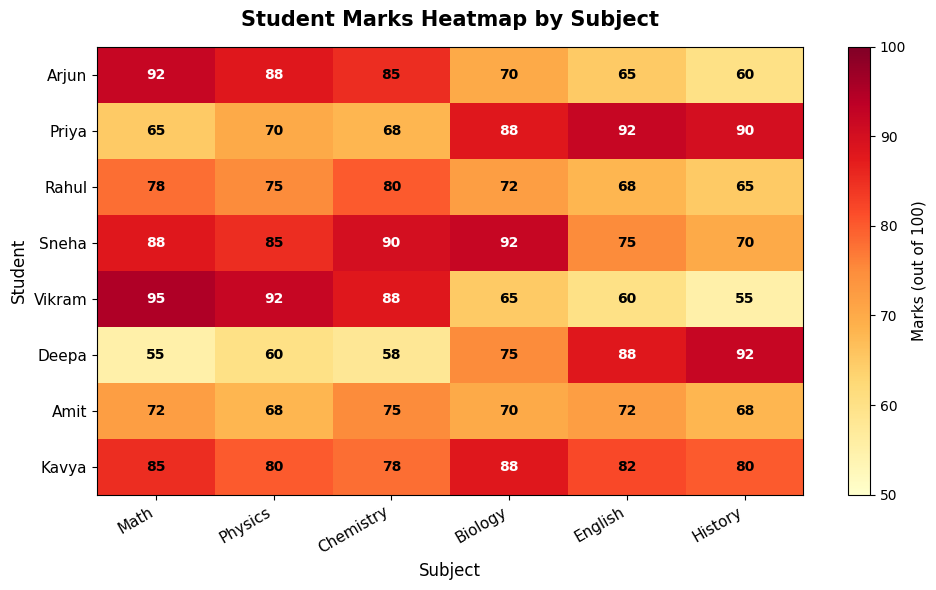

Heatmap saved!


In [15]:
# --- HEATMAP with imshow ---
fig, ax = plt.subplots(figsize=(10, 6))

# imshow renders the 2D array as a colored grid
# aspect='auto' adjusts the cell size to fill the figure
# vmin and vmax set the range for the colormap (0=dark, 100=bright)
im = ax.imshow(marks_matrix, cmap='YlOrRd', aspect='auto', vmin=50, vmax=100)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Marks (out of 100)', fontsize=11)

# Set tick labels for both axes
# You must set ticks at the correct integer positions first, then set labels
ax.set_xticks(np.arange(len(subjects)))       # positions: 0, 1, 2, 3, 4, 5
ax.set_yticks(np.arange(len(students)))        # positions: 0, 1, 2, 3, 4, 5, 6, 7
ax.set_xticklabels(subjects, fontsize=11)      # replace numbers with subject names
ax.set_yticklabels(students, fontsize=11)      # replace numbers with student names

# Rotate x-axis labels to avoid overlap
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Add value labels inside each cell
# Loop through all rows and columns and write the number in the cell
for i in range(len(students)):
    for j in range(len(subjects)):
        value = marks_matrix[i, j]
        # Choose text color based on background: dark text on light cells, white on dark
        text_color = 'white' if value > 85 else 'black'
        ax.text(j, i, str(value),
                ha='center', va='center',
                fontsize=10, fontweight='bold', color=text_color)

ax.set_title('Student Marks Heatmap by Subject', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Subject', fontsize=12)
ax.set_ylabel('Student', fontsize=12)

plt.tight_layout()
plt.savefig('day17_charts/6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved!')

In [16]:
# Heatmap from pivot_table - the real-world workflow
# In practice you will have a long-format DataFrame, not a ready matrix
# pivot_table converts it to 2D format

# Long-format DataFrame (how data usually comes)
rows_data = []
for student in students:
    for j, subject in enumerate(subjects):
        idx = students.index(student)
        rows_data.append({
            'Student': student,
            'Subject': subject,
            'Marks': marks_matrix[idx, j]
        })

df_long = pd.DataFrame(rows_data)
print('Long format DataFrame:')
print(df_long.head(8))
print(f'\nTotal rows: {len(df_long)}')

Long format DataFrame:
  Student    Subject  Marks
0   Arjun       Math     92
1   Arjun    Physics     88
2   Arjun  Chemistry     85
3   Arjun    Biology     70
4   Arjun    English     65
5   Arjun    History     60
6   Priya       Math     65
7   Priya    Physics     70

Total rows: 48


In [17]:
# Convert long format to pivot table (2D matrix format for heatmap)
pivot = df_long.pivot_table(index='Student', columns='Subject', values='Marks')

print('Pivot table (2D format):')
print(pivot)
print('\nNow this pivot table can be passed directly to imshow()')

Pivot table (2D format):
Subject  Biology  Chemistry  English  History  Math  Physics
Student                                                     
Amit        70.0       75.0     72.0     68.0  72.0     68.0
Arjun       70.0       85.0     65.0     60.0  92.0     88.0
Deepa       75.0       58.0     88.0     92.0  55.0     60.0
Kavya       88.0       78.0     82.0     80.0  85.0     80.0
Priya       88.0       68.0     92.0     90.0  65.0     70.0
Rahul       72.0       80.0     68.0     65.0  78.0     75.0
Sneha       92.0       90.0     75.0     70.0  88.0     85.0
Vikram      65.0       88.0     60.0     55.0  95.0     92.0

Now this pivot table can be passed directly to imshow()


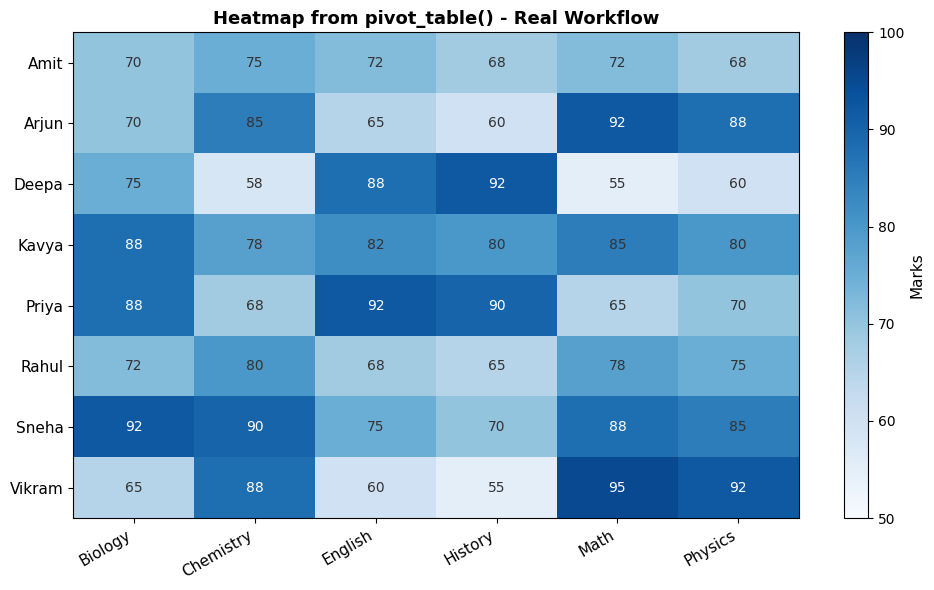

Pivot heatmap saved!


In [18]:
# Heatmap from pivot table
fig, ax = plt.subplots(figsize=(10, 6))

# pivot.values converts DataFrame to NumPy array
im = ax.imshow(pivot.values, cmap='Blues', aspect='auto', vmin=50, vmax=100)
plt.colorbar(im, ax=ax).set_label('Marks', fontsize=11)

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticklabels(pivot.index, fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i,j]:.0f}',
                ha='center', va='center', fontsize=10,
                color='white' if pivot.values[i,j] > 85 else '#333')

ax.set_title('Heatmap from pivot_table() - Real Workflow', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day17_charts/6b_heatmap_pivot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Pivot heatmap saved!')

---

# Part 7: Pandas .plot() - The Shortcut You Will Use Daily

## Why Pandas .plot() Exists

In real work, your data is already in a DataFrame. Writing Matplotlib code manually means:
1. Extract columns from DataFrame
2. Pass them to plt.plot()
3. Set labels, legend, etc.

Pandas .plot() skips all that. It reads directly from the DataFrame and plots in one line. Column names become axis labels automatically. The index becomes the x-axis.

Pandas .plot() is Matplotlib under the hood. It just wraps the most common operations in a convenient one-liner.

---

## Important Parameters

- `kind='line'` - line plot (default)
- `kind='bar'` - vertical bar chart
- `kind='barh'` - horizontal bar chart
- `kind='hist'` - histogram
- `kind='pie'` - pie chart
- `kind='scatter'` - scatter plot (requires `x=` and `y=` column names)
- `subplots=True` - each column gets its own subplot in one figure
- `stacked=True` - stacked bar or area chart
- `figsize=(w, h)` - figure size
- `color=` - colors for each line/bar
- `bins=` - for histogram
- `autopct=` - for pie chart

In [19]:
# --- DATA: Monthly Sales for 5 Products ---
np.random.seed(15)

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
products = ['Laptop', 'Mobile', 'Tablet', 'Headphones', 'Charger']

# Realistic sales numbers with seasonal patterns
base_sales = {
    'Laptop':     [120, 100, 110, 105, 115, 90, 95, 130, 140, 135, 160, 200],
    'Mobile':     [300, 280, 290, 310, 320, 350, 360, 340, 300, 310, 380, 450],
    'Tablet':     [80, 75, 82, 78, 85, 70, 72, 90, 95, 88, 110, 140],
    'Headphones': [150, 140, 155, 160, 170, 165, 180, 175, 160, 170, 200, 250],
    'Charger':    [200, 190, 205, 210, 215, 220, 225, 215, 200, 210, 240, 300],
}

# Add small random noise
sales_df = pd.DataFrame(base_sales, index=months)
noise = np.random.randint(-10, 10, sales_df.shape)
sales_df = sales_df + noise

print('Monthly Sales DataFrame:')
print(sales_df)
print(f'\nShape: {sales_df.shape} (12 months x 5 products)')

Monthly Sales DataFrame:
     Laptop  Mobile  Tablet  Headphones  Charger
Jan     118     302      75         140      197
Feb     101     285      82         143      180
Mar     110     295      76         154      202
Apr     100     319      80         163      215
May     111     325      93         177      206
Jun      80     342      71         173      211
Jul      93     356      71         172      223
Aug     128     345      83         169      212
Sep     132     300      85         155      197
Oct     144     305      91         179      217
Nov     166     378     112         204      242
Dec     191     442     142         259      300

Shape: (12, 5) (12 months x 5 products)


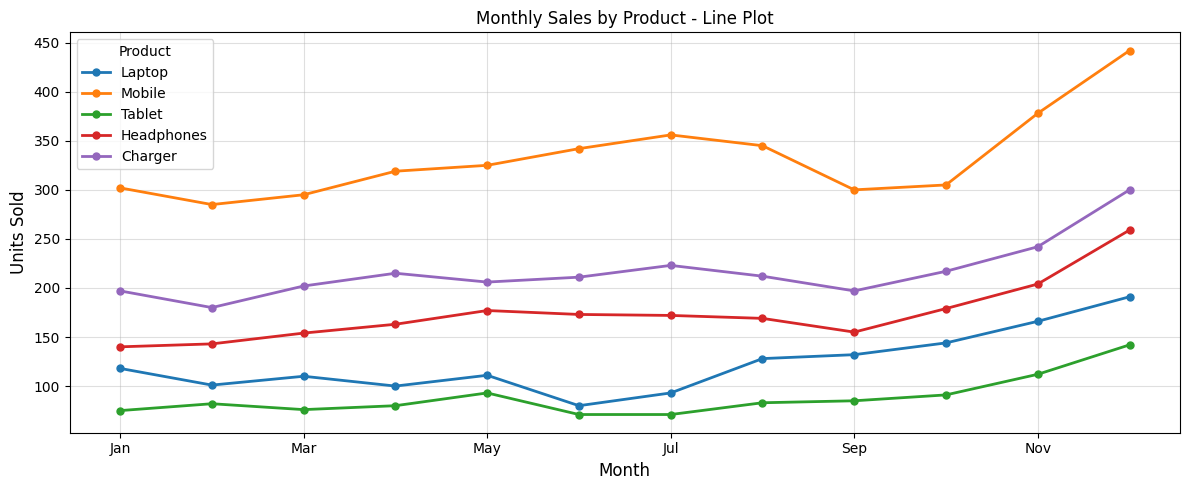

Pandas line plot saved!


In [20]:
# --- PANDAS PLOT: Line chart (default) ---
# One line per column (product)
# Index (months) automatically becomes x-axis

ax = sales_df.plot(
    kind='line',
    figsize=(12, 5),
    linewidth=2,
    marker='o',
    markersize=5,
    title='Monthly Sales by Product - Line Plot'
)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Units Sold', fontsize=12)
ax.legend(title='Product', fontsize=10)
ax.grid(True, alpha=0.4)

# ax is returned by .plot() so you can still customize using OOP syntax
plt.tight_layout()
plt.savefig('day17_charts/7a_pandas_line.png', dpi=150, bbox_inches='tight')
plt.show()
print('Pandas line plot saved!')

Annual sales per product:
Laptop        1474
Mobile        3994
Tablet        1061
Headphones    2088
Charger       2602
dtype: int64


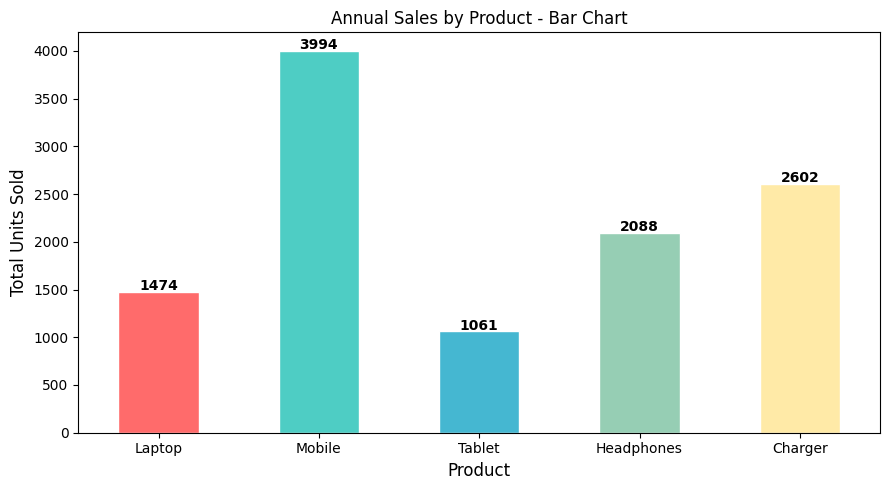

In [21]:
# --- PANDAS PLOT: Bar chart ---
# Total annual sales per product
annual_sales = sales_df.sum()
print('Annual sales per product:')
print(annual_sales)

# Plotting a Series (not DataFrame)
ax = annual_sales.plot(
    kind='bar',
    figsize=(9, 5),
    color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'],
    edgecolor='white',
    title='Annual Sales by Product - Bar Chart'
)

ax.set_xlabel('Product', fontsize=12)
ax.set_ylabel('Total Units Sold', fontsize=12)
ax.tick_params(axis='x', rotation=0)

# Add value labels on top of bars
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{bar.get_height():.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('day17_charts/7b_pandas_bar.png', dpi=150, bbox_inches='tight')
plt.show()

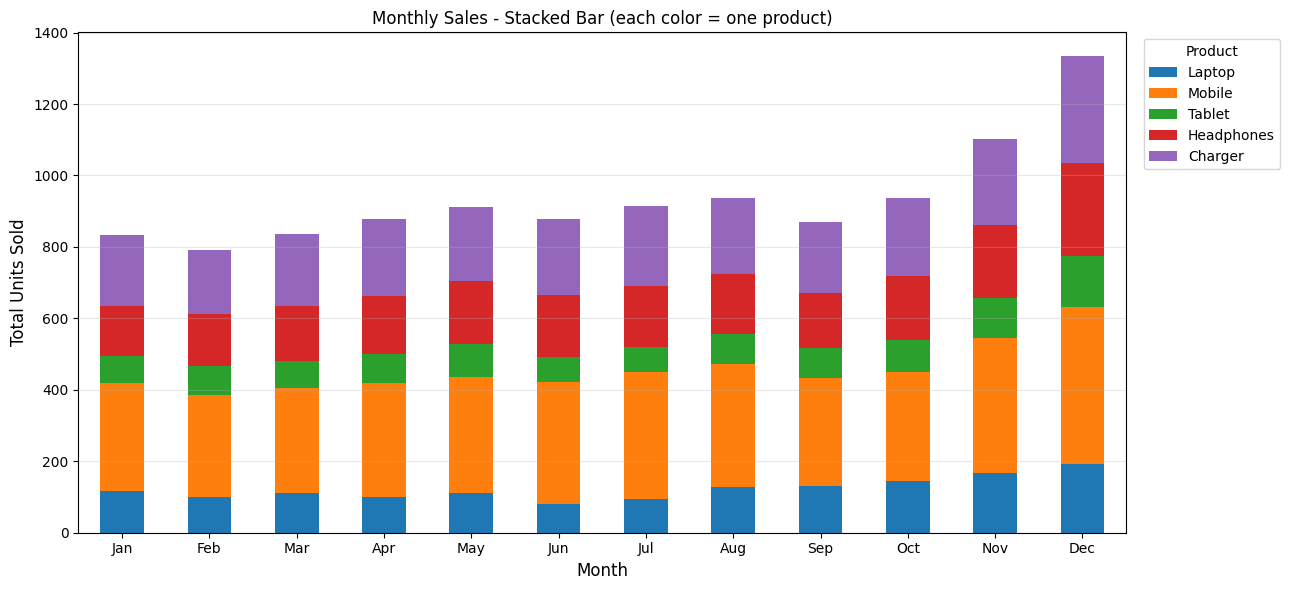

In [22]:
# --- PANDAS PLOT: Stacked Bar ---
# See each month's total and how each product contributes to it

ax = sales_df.plot(
    kind='bar',
    stacked=True,    # THIS makes it stacked instead of grouped
    figsize=(13, 6),
    title='Monthly Sales - Stacked Bar (each color = one product)'
)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Units Sold', fontsize=12)
ax.legend(title='Product', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('day17_charts/7c_pandas_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

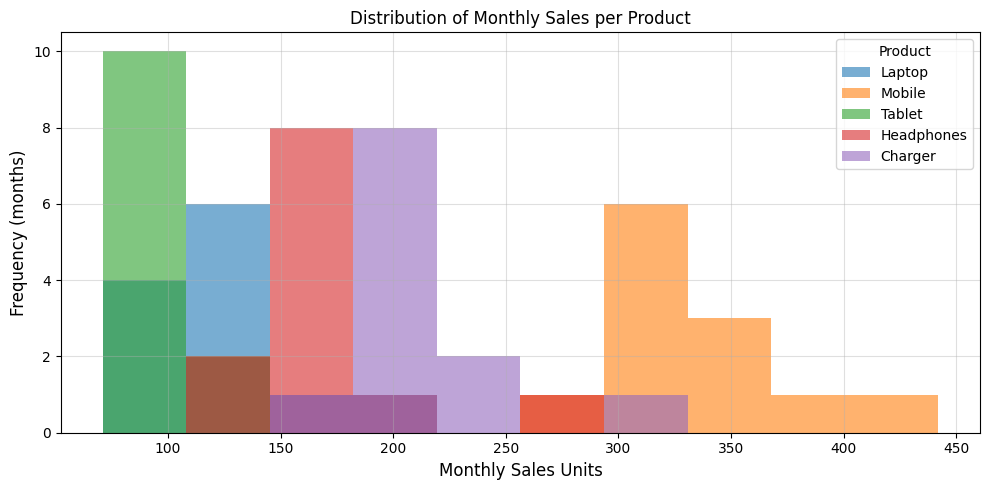

In [23]:
# --- PANDAS PLOT: Histogram ---
# Shows distribution of sales values across all months for each product

ax = sales_df.plot(
    kind='hist',
    bins=10,
    figsize=(10, 5),
    alpha=0.6,       # transparency so overlapping histograms are visible
    title='Distribution of Monthly Sales per Product'
)

ax.set_xlabel('Monthly Sales Units', fontsize=12)
ax.set_ylabel('Frequency (months)', fontsize=12)
ax.legend(title='Product')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('day17_charts/7d_pandas_hist.png', dpi=150, bbox_inches='tight')
plt.show()

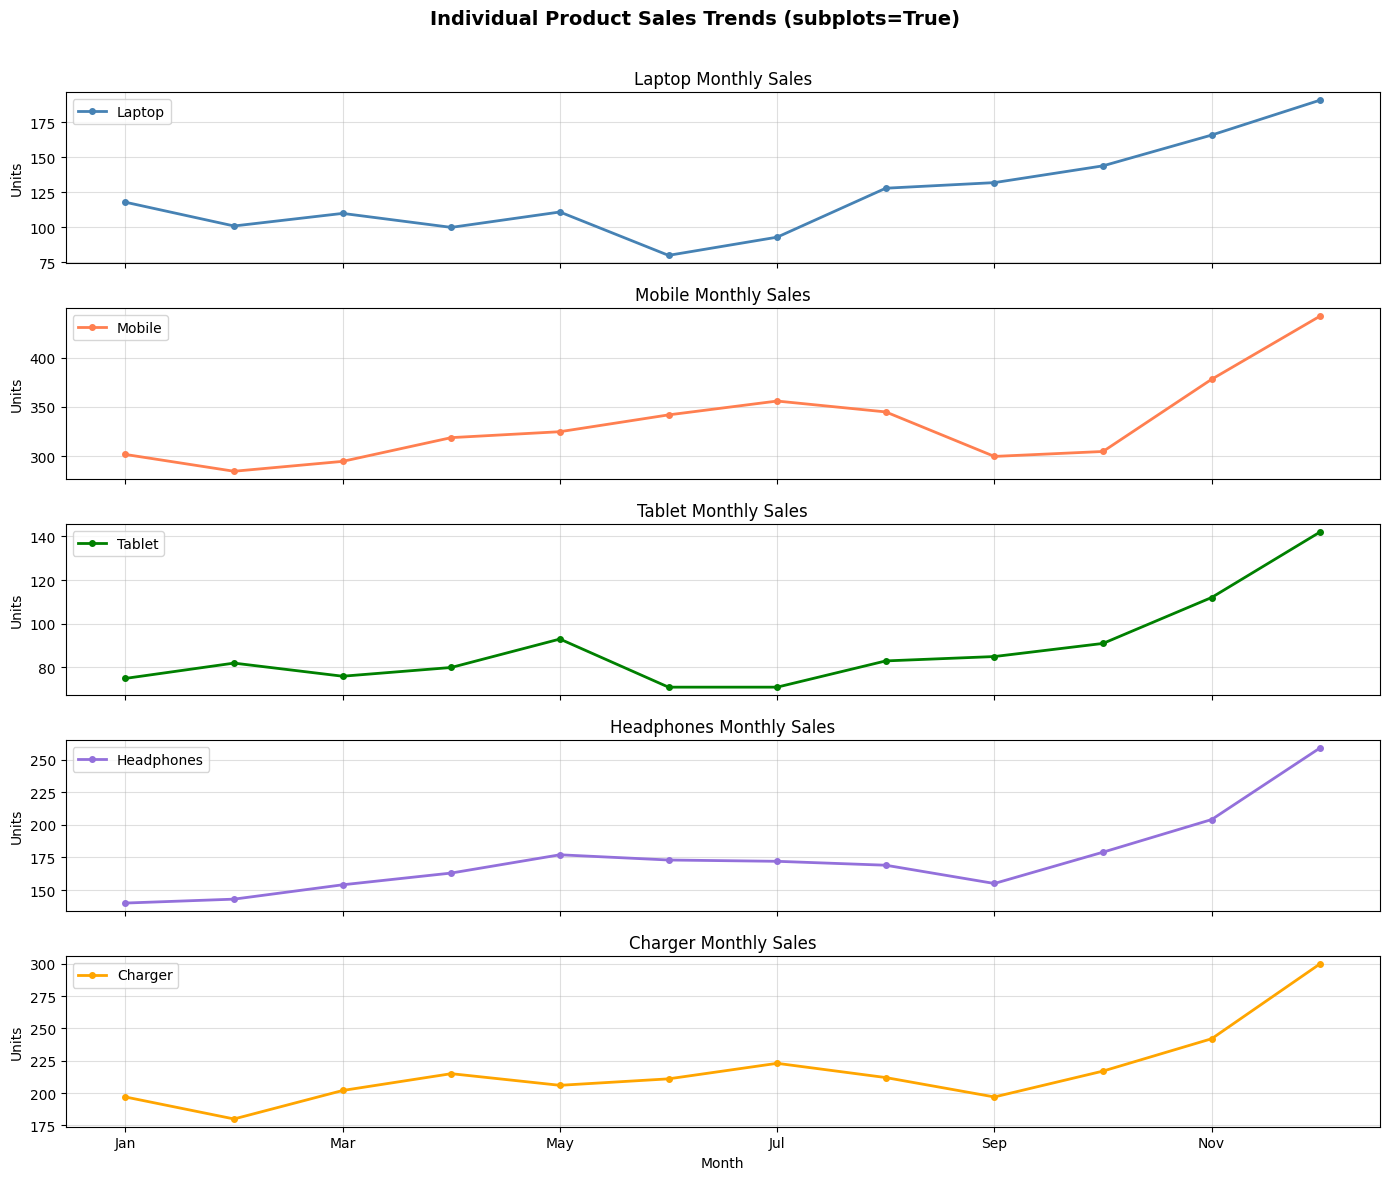

All pandas plots saved!


In [24]:
# --- PANDAS PLOT: subplots=True ---
# Each column (product) gets its own subplot, all in one figure
# This is very powerful - one line of code creates 5 separate charts

axes = sales_df.plot(
    kind='line',
    subplots=True,    # each column = separate subplot
    figsize=(14, 12),
    layout=(5, 1),    # 5 rows, 1 column layout
    linewidth=2,
    marker='o',
    markersize=4,
    color=['steelblue', 'coral', 'green', 'mediumpurple', 'orange'],
    title=[f'{p} Monthly Sales' for p in products]  # separate title per subplot
)

# axes is a 2D array here. Flatten to loop easily.
for ax in axes.flatten():
    ax.set_xlabel('Month')
    ax.set_ylabel('Units')
    ax.grid(True, alpha=0.4)

plt.suptitle('Individual Product Sales Trends (subplots=True)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('day17_charts/7e_pandas_subplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('All pandas plots saved!')

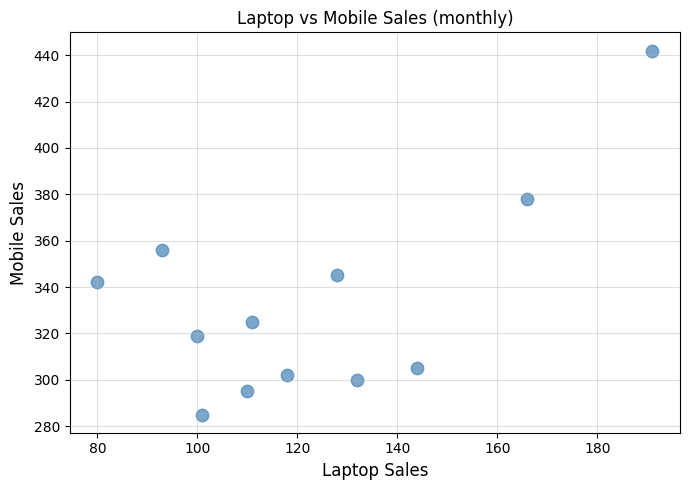

In [25]:
# --- PANDAS PLOT: Scatter (requires x= and y= columns) ---
# Only works with DataFrame, not Series

ax = sales_df.plot(
    kind='scatter',
    x='Laptop',
    y='Mobile',
    figsize=(7, 5),
    color='steelblue',
    s=80,
    alpha=0.7,
    title='Laptop vs Mobile Sales (monthly)'
)

ax.set_xlabel('Laptop Sales', fontsize=12)
ax.set_ylabel('Mobile Sales', fontsize=12)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('day17_charts/7f_pandas_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---

# GitHub File 1: subplots_3d.py - The Portfolio Dashboard

**2x2 subplot grid:**
- Top-left: Colored scatter (marks vs attendance, color = grade)
- Top-right: 3D scatter (random xyz data)
- Bottom-left: Surface plot (sin wave meshgrid)
- Bottom-right: Heatmap (student x subject)

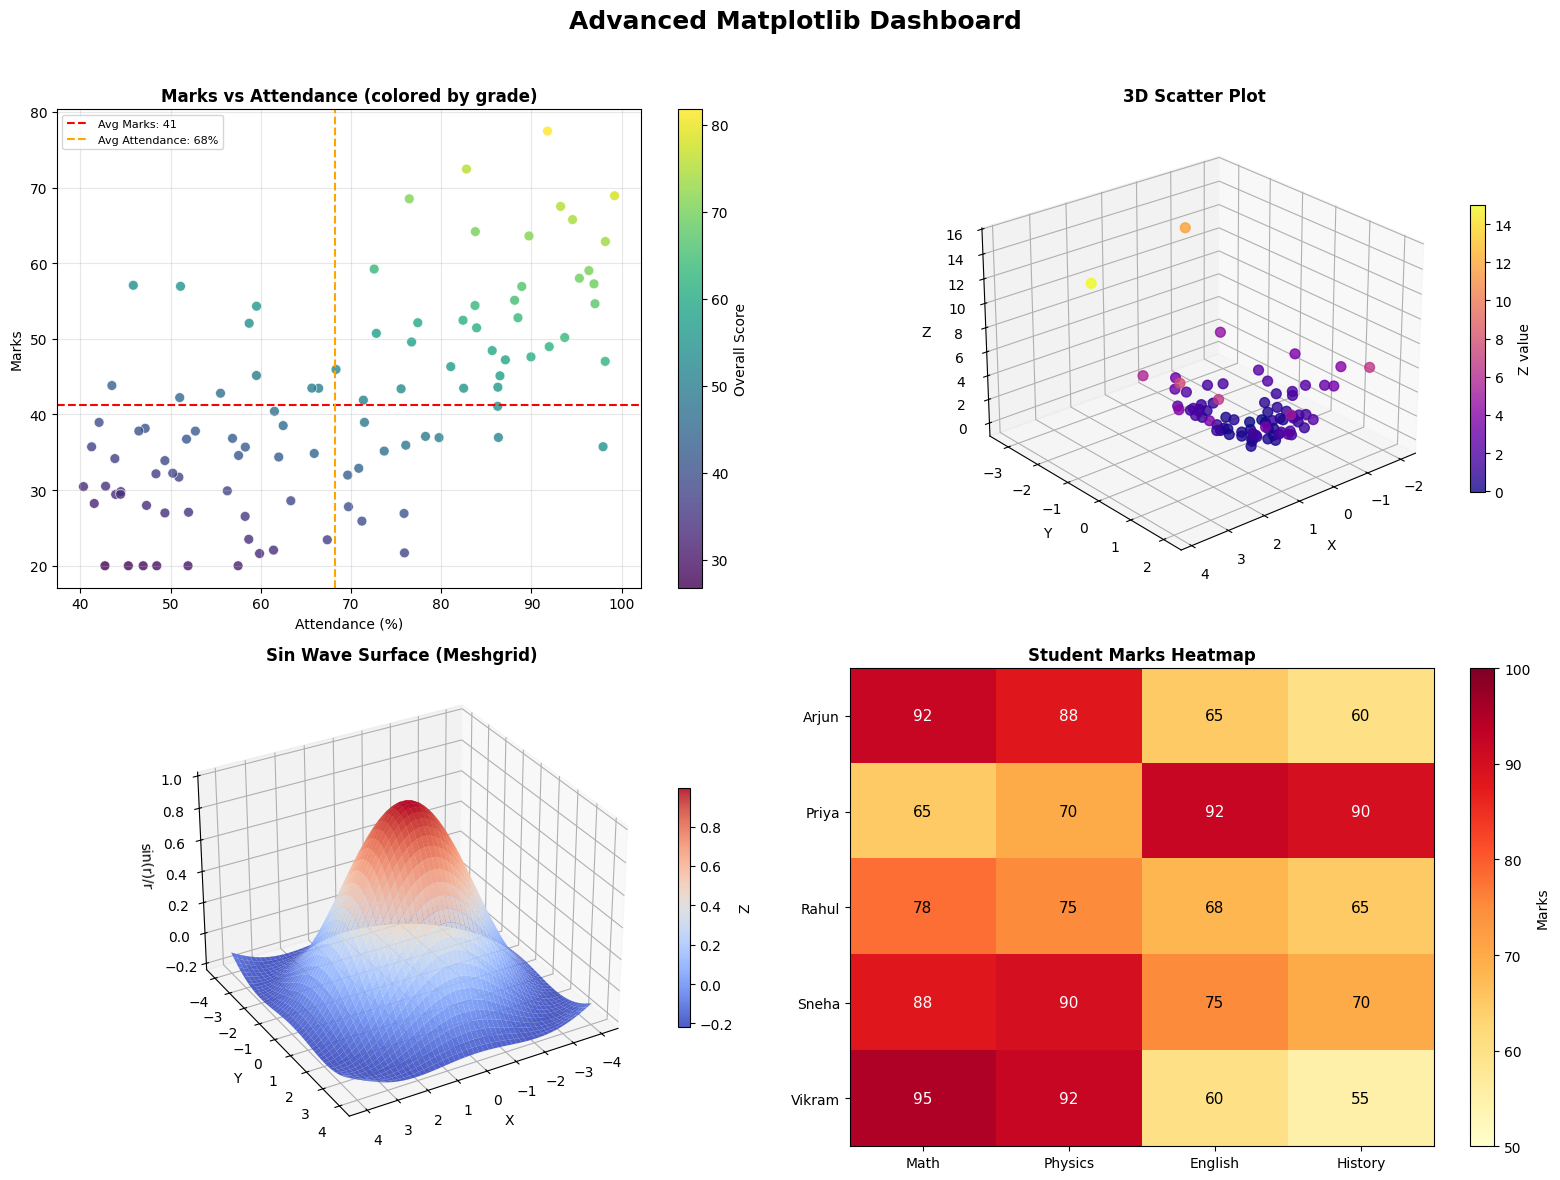

2x2 Dashboard saved to day17_charts/dashboard_2x2.png


In [26]:
# ============================================================
# day17_matplotlib_advanced/subplots_3d.py
# 2x2 Dashboard: Scatter, 3D, Surface, Heatmap
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import os

os.makedirs('day17_charts', exist_ok=True)
np.random.seed(42)

# ---- Create the 2x2 figure ----
# subplot_kw lets you pass default kwargs to ALL subplots
# We cannot use it here because one plot is 3D and others are 2D
# So we create 3 normal subplots and 1 3D subplot manually

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Advanced Matplotlib Dashboard', fontsize=18, fontweight='bold', y=0.98)

# ---- TOP-LEFT: Colored Scatter ----
ax1 = fig.add_subplot(2, 2, 1)  # 2 rows, 2 cols, position 1

n = 100
attendance = np.random.uniform(40, 100, n)
marks = np.clip(attendance * 0.6 + np.random.normal(0, 12, n), 20, 100)
grade_score = (marks * 0.7 + attendance * 0.3)

sc1 = ax1.scatter(attendance, marks, c=grade_score, cmap='viridis',
                  s=50, alpha=0.8, edgecolors='white', linewidths=0.5)
plt.colorbar(sc1, ax=ax1, label='Overall Score')
ax1.axhline(y=marks.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Avg Marks: {marks.mean():.0f}')
ax1.axvline(x=attendance.mean(), color='orange', linestyle='--', linewidth=1.5,
            label=f'Avg Attendance: {attendance.mean():.0f}%')
ax1.set_title('Marks vs Attendance (colored by grade)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Attendance (%)')
ax1.set_ylabel('Marks')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ---- TOP-RIGHT: 3D Scatter ----
ax2 = fig.add_subplot(2, 2, 2, projection='3d')  # 3D projection

x3 = np.random.normal(0, 1, 80)
y3 = np.random.normal(0, 1, 80)
z3 = x3**2 + y3**2 + np.random.normal(0, 0.3, 80)

sc2 = ax2.scatter3D(x3, y3, z3, c=z3, cmap='plasma', s=50, alpha=0.8)
plt.colorbar(sc2, ax=ax2, shrink=0.6, label='Z value')
ax2.set_title('3D Scatter Plot', fontsize=12, fontweight='bold')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.view_init(elev=25, azim=50)

# ---- BOTTOM-LEFT: Surface Plot ----
ax3 = fig.add_subplot(2, 2, 3, projection='3d')

x_surf = np.linspace(-4, 4, 50)
y_surf = np.linspace(-4, 4, 50)
XX, YY = np.meshgrid(x_surf, y_surf)
R = np.sqrt(XX**2 + YY**2)
ZZ = np.sin(R) / (R + 1e-6)

surf = ax3.plot_surface(XX, YY, ZZ, cmap='coolwarm', alpha=0.9)
plt.colorbar(surf, ax=ax3, shrink=0.5, label='Z')
ax3.set_title('Sin Wave Surface (Meshgrid)', fontsize=12, fontweight='bold')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('sin(r)/r')
ax3.view_init(elev=30, azim=60)

# ---- BOTTOM-RIGHT: Heatmap ----
ax4 = fig.add_subplot(2, 2, 4)

students = ['Arjun', 'Priya', 'Rahul', 'Sneha', 'Vikram']
subjects = ['Math', 'Physics', 'English', 'History']
marks_hm = np.array([
    [92, 88, 65, 60],
    [65, 70, 92, 90],
    [78, 75, 68, 65],
    [88, 90, 75, 70],
    [95, 92, 60, 55],
])

im = ax4.imshow(marks_hm, cmap='YlOrRd', aspect='auto', vmin=50, vmax=100)
plt.colorbar(im, ax=ax4, label='Marks')

ax4.set_xticks(np.arange(len(subjects)))
ax4.set_yticks(np.arange(len(students)))
ax4.set_xticklabels(subjects)
ax4.set_yticklabels(students)

for i in range(len(students)):
    for j in range(len(subjects)):
        c = 'white' if marks_hm[i,j] > 85 else 'black'
        ax4.text(j, i, str(marks_hm[i,j]), ha='center', va='center', fontsize=11, color=c)

ax4.set_title('Student Marks Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('day17_charts/dashboard_2x2.png', dpi=150, bbox_inches='tight')
plt.show()
print('2x2 Dashboard saved to day17_charts/dashboard_2x2.png')

---

# GitHub File 2: pandas_plot.py - Monthly Sales Visualization

Sales DataFrame created


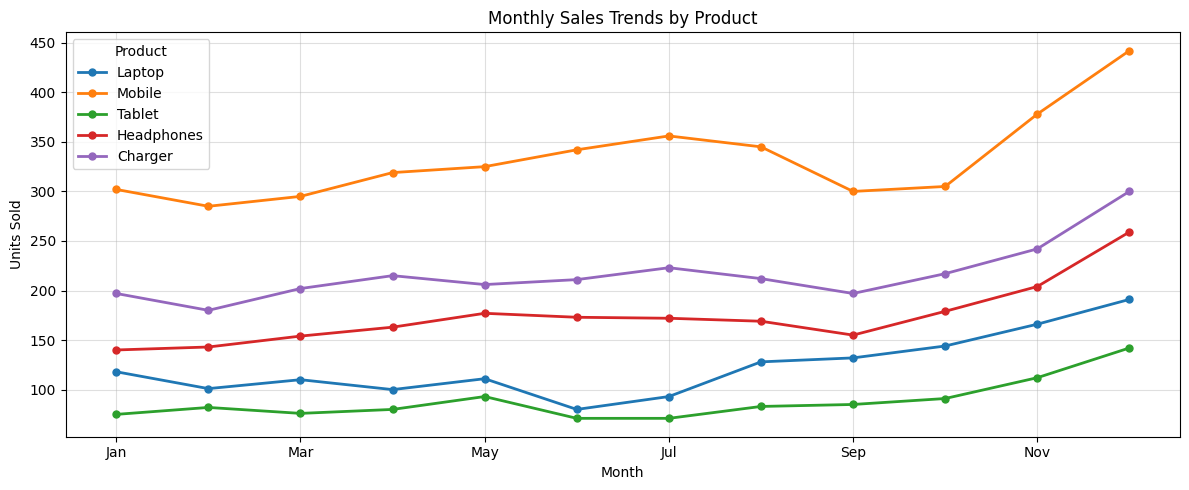

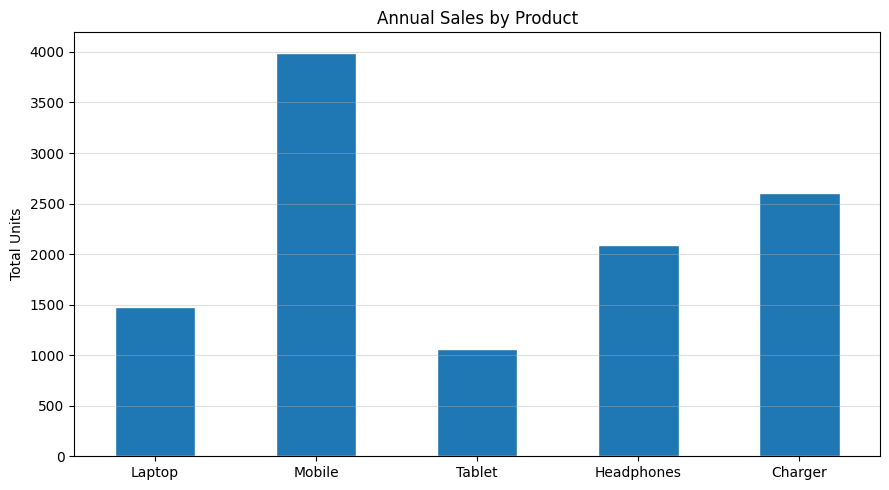

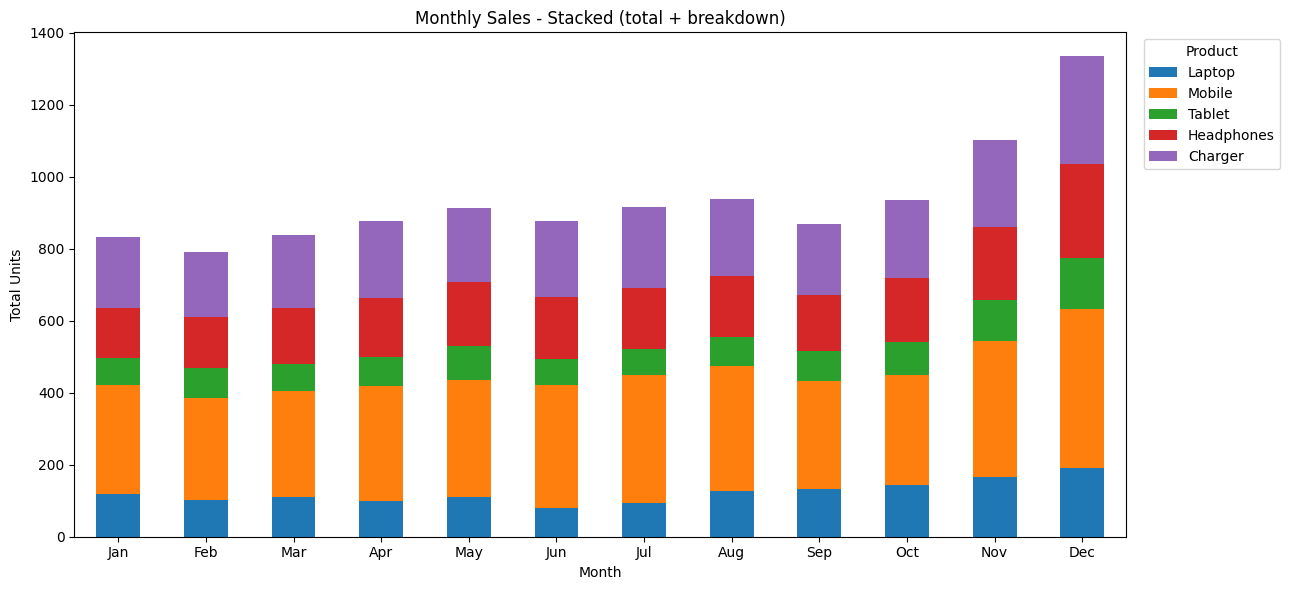

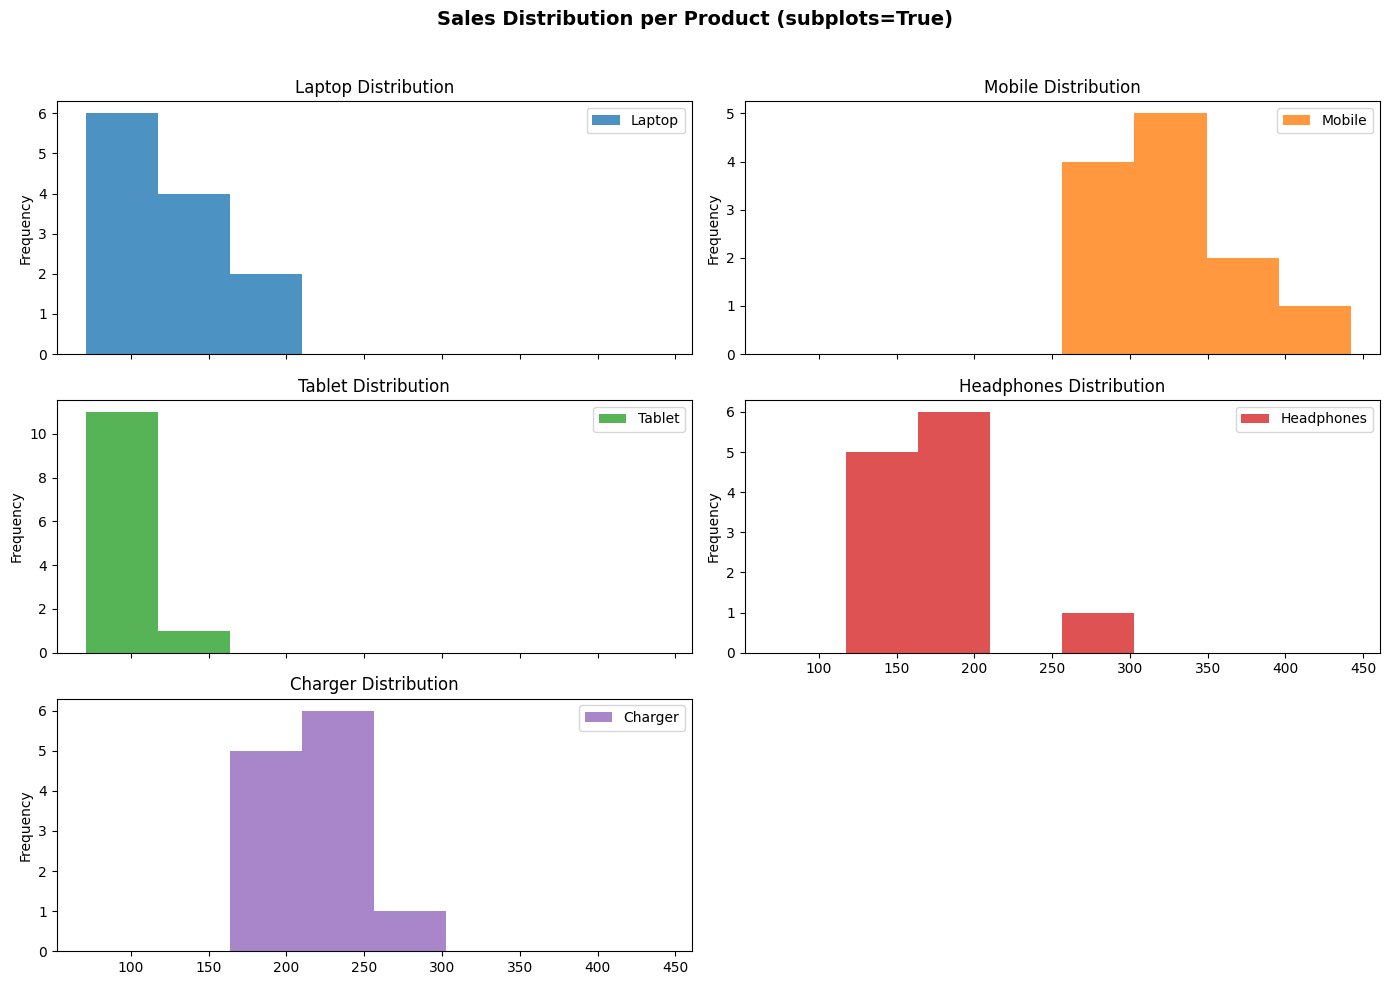

All pandas plots saved in day17_charts/


In [27]:
# ============================================================
# day17_matplotlib_advanced/pandas_plot.py
# Monthly Sales DataFrame - Pandas .plot() all chart types
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

os.makedirs('day17_charts', exist_ok=True)
np.random.seed(15)

# Create Monthly Sales DataFrame: 5 products x 12 months
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sales_data = {
    'Laptop':     [120,100,110,105,115,90,95,130,140,135,160,200],
    'Mobile':     [300,280,290,310,320,350,360,340,300,310,380,450],
    'Tablet':     [80,75,82,78,85,70,72,90,95,88,110,140],
    'Headphones': [150,140,155,160,170,165,180,175,160,170,200,250],
    'Charger':    [200,190,205,210,215,220,225,215,200,210,240,300],
}
df = pd.DataFrame(sales_data, index=months)
df += np.random.randint(-10, 10, df.shape)

print('Sales DataFrame created')

# ---- Line Plot: all products on one chart ----
ax = df.plot(kind='line', figsize=(12, 5), linewidth=2, marker='o', markersize=5,
             title='Monthly Sales Trends by Product')
ax.set_xlabel('Month')
ax.set_ylabel('Units Sold')
ax.legend(title='Product')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('day17_charts/pd_line.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Bar Plot: annual totals ----
annual = df.sum()
ax = annual.plot(kind='bar', figsize=(9, 5), edgecolor='white',
                 title='Annual Sales by Product')
ax.set_ylabel('Total Units')
ax.tick_params(axis='x', rotation=0)
ax.grid(True, alpha=0.4, axis='y')
plt.tight_layout()
plt.savefig('day17_charts/pd_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Stacked Bar: all products per month ----
ax = df.plot(kind='bar', stacked=True, figsize=(13, 6),
             title='Monthly Sales - Stacked (total + breakdown)')
ax.set_xlabel('Month')
ax.set_ylabel('Total Units')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Product', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('day17_charts/pd_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Histogram: with subplots=True ----
axes = df.plot(kind='hist', subplots=True, bins=8, figsize=(14, 10),
               layout=(3, 2), alpha=0.8,
               title=[f'{p} Distribution' for p in df.columns])
plt.suptitle('Sales Distribution per Product (subplots=True)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('day17_charts/pd_hist_subplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('All pandas plots saved in day17_charts/')

---

# Complete Reference: Day 17 Cheat Sheet

---

## plt syntax vs fig/ax syntax - Side by Side

```python
# PLT SYNTAX (quick)
plt.figure(figsize=(8,5))
plt.plot(x, y)
plt.title('Title')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

# FIG/AX SYNTAX (professional)
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(x, y)
ax.set_title('Title')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()
```

---

## Subplots Grid Access

```python
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0]  # top-left
axes[0, 1]  # top-right
axes[1, 0]  # bottom-left
axes[1, 1]  # bottom-right

# Or flatten for looping:
for ax in axes.flatten():
    ax.set_xlabel('X')
```

---

## Colormap Quick Reference

```
viridis    -> professional, colorblind-safe. Use this always.
plasma     -> similar to viridis, more vivid
coolwarm   -> blue-white-red, for diverging data (negative to positive)
jet        -> flashy rainbow, perceptually misleading. Avoid.
Blues      -> single color gradient, simple and clean
YlOrRd     -> yellow to orange to red, great for heatmaps
```

---

## 3D Plots

```python
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter3D(x, y, z, c=z, cmap='viridis')
ax.plot3D(x, y, z, color='red')
ax.plot_surface(XX, YY, ZZ, cmap='plasma')   # needs meshgrid
ax.contour(XX, YY, ZZ)                        # topographic lines
ax.contourf(XX, YY, ZZ)                       # filled contour
ax.set_zlabel('Z axis')
ax.view_init(elev=30, azim=45)
```

---

## Meshgrid

```python
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
XX, YY = np.meshgrid(x, y)     # creates 50x50 grids
ZZ = np.sin(XX) * np.cos(YY)   # evaluate function at all grid points
```

---

## Heatmap

```python
im = ax.imshow(matrix_2d, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
plt.colorbar(im, ax=ax)
ax.set_xticks(np.arange(n_cols))
ax.set_yticks(np.arange(n_rows))
ax.set_xticklabels(col_labels)
ax.set_yticklabels(row_labels)

# From DataFrame:
pivot = df.pivot_table(index='row_col', columns='col_col', values='value_col')
ax.imshow(pivot.values, cmap='Blues')
```

---

## Pandas .plot() Quick Reference

```python
df.plot(kind='line')                          # line chart
df.plot(kind='bar')                           # bar chart
df.plot(kind='barh')                          # horizontal bar
df.plot(kind='hist', bins=20)                 # histogram
df.plot(kind='scatter', x='col1', y='col2')   # scatter
df.plot(kind='bar', stacked=True)             # stacked bar
df.plot(subplots=True, layout=(r,c))          # each col = subplot
series.plot(kind='pie', autopct='%1.1f%%')    # pie chart
```

---

## Annotations

```python
ax.text(x, y, 'text', fontsize=10, color='red')     # simple text
ax.annotate('text', xy=(x,y), xytext=(tx,ty),       # text + arrow
            arrowprops=dict(arrowstyle='->', color='red'))
ax.axhline(y=value, color='red', linestyle='--')     # horizontal line
ax.axvline(x=value, color='blue', linestyle=':')     # vertical line
```

---
